In [1]:
!pip install seaborn

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset



In [3]:
df = sns.load_dataset('titanic')

Display First 5 Rows

In [4]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


Dataset Information

In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f


Remove Duplicate Rows

In [6]:
df = df.drop_duplicates()
print("Duplicates Removed")

Duplicates Removed


Handle Missing Values

In [8]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['deck'] = df['deck'].astype(str)
df['deck'] = df['deck'].replace('nan', 'Unknown')

Check Missing Values Again

In [9]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


Detect & Remove Outliers (Age)

In [10]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['age'] >= lower) & (df['age'] <= upper)]


Encode Categorical Variables

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['sex','embarked','class','who','adult_male','deck','embark_town','alive','alone']

for col in cols:
    df[col] = le.fit_transform(df[col].astype(str))

Save Cleaned Dataset

In [12]:
df.to_csv("cleaned_titanic.csv", index=False)

**Visualization**

Histogram

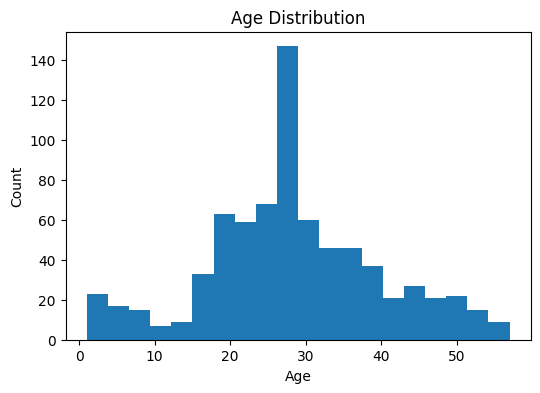

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Box Plot

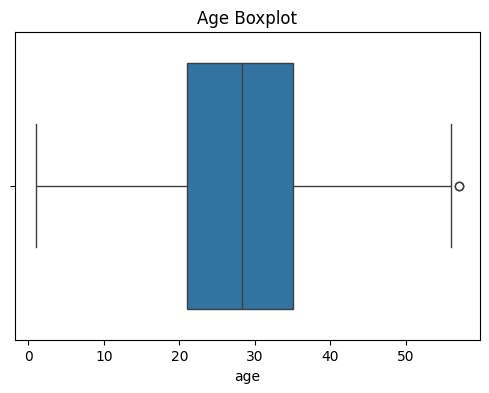

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title("Age Boxplot")
plt.show()

Bar Chart

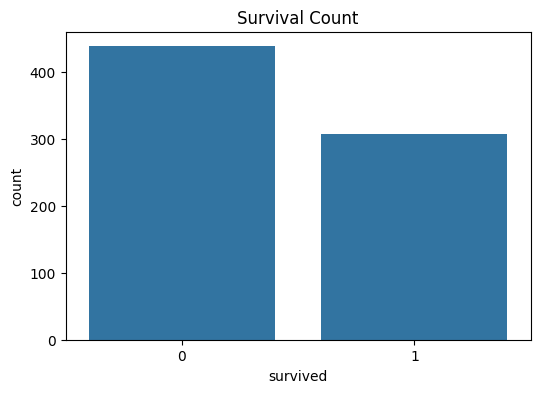

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

Scatter Plot

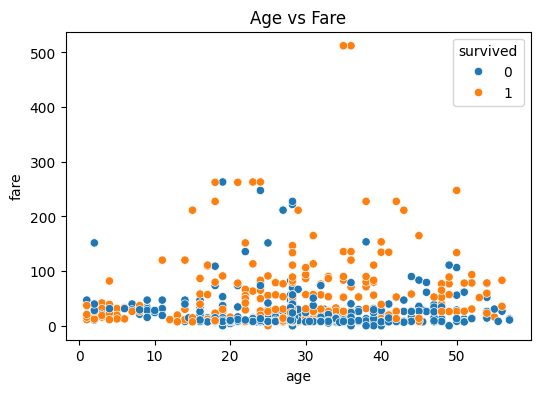

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title("Age vs Fare")
plt.show()

Correlation Heatmap

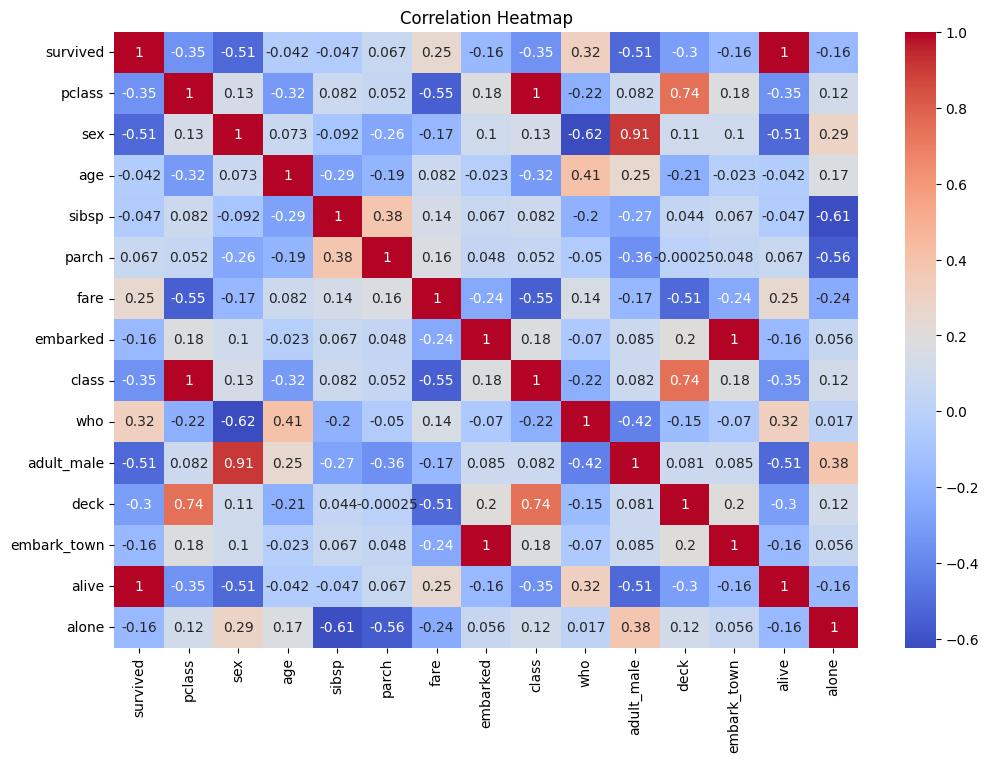

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Pie Chart

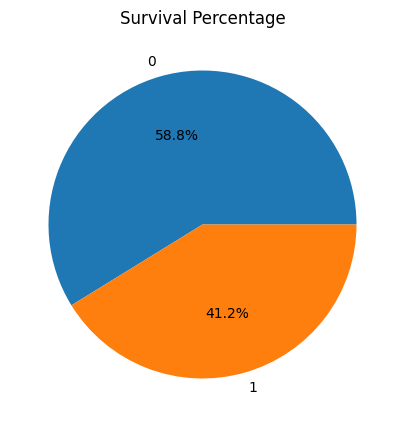

In [18]:
df['survived'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5)
)
plt.title("Survival Percentage")
plt.ylabel("")
plt.show()

Insights

In [19]:
print("Average Age :", round(df['age'].mean(),2))
print("Average Fare :", round(df['fare'].mean(),2))
print("Passengers :", len(df))
print("Survival Rate :", round(df['survived'].mean()*100,2),"%")

Average Age : 28.38
Average Fare : 34.03
Passengers : 745
Survival Rate : 41.21 %
